In [1]:
import ROOT
import rich
import os
import yaml
from scripts.create_crosspog_json import pt_eta_correction, CorrectionSet, emb_doublemuon_correction
ROOT.PyConfig.IgnoreCommandLineOptions = True
ROOT.gROOT.SetBatch(ROOT.kTRUE)
# for keeping the histograms in memory
ROOT.TH1.AddDirectory(0)

Welcome to JupyROOT 6.24/02


In [2]:
def add_corrections(yamlfile, correctionset, era):
    with open(yamlfile, "r") as stream:
        correction_db = yaml.safe_load(stream)
    for correction in correction_db:
        print(f"Adding {correction}")
        correction = pt_eta_correction(
            tag=correction_db[correction]["name"],
            name=correction,
            configfile=yamlfile,
            era=era,
            outdir="output/jsons",
            data_only=False,
        )
        correction.generate_scheme()
        correctionset.add_correction(correction.correctionset)

In [3]:
# Muon 2018 scale factors

channel = "muon"
era = "2018UL"
if not os.path.exists("output/jsons"):
    os.makedirs("output/jsons")
correctionset = CorrectionSet("Embedding2018UL")
add_corrections(f"settings/settings_{channel}_{era}.yaml", correctionset, era)
EmbSelEff = emb_doublemuon_correction(
    tag="EmbSelEff",
    name="m_sel_trg_kit_ratio",
    configfile=f"settings/settings_embeddingselection_{era}_xpog.yaml",
    triggernames=["Trg17_pt_eta_bins", "Trg8_pt_eta_bins"],
    era=era,
    outdir="output/jsons",
    data_only=True,
)
EmbSelEff.generate_scheme()
EmbSelEffID = pt_eta_correction(
            tag="EmbSelEffID",
            name="EmbID_pt_eta_bins",
            configfile=f"settings/settings_embeddingselection_{era}.yaml",
            era=era,
            outdir="output/jsons",
            data_only=True,
        )
EmbSelEffID.generate_scheme()
correctionset.add_correction(EmbSelEff)
correctionset.add_correction(EmbSelEffID)
correctionset.write_json(f"output/jsons/{channel}_{era}.json")


Adding ID_pt_bins_inc_eta
Getting  ID_pt_bins_inc_eta from  output/muon_TP_Data_2018UL_Fits_ID_pt_bins_inc_eta.root
Getting  ID_pt_bins_inc_eta from  output/muon_TP_Embedding_2018UL_Fits_ID_pt_bins_inc_eta.root
Getting  ID_pt_bins_inc_eta from  output/muon_TP_DY_2018UL_Fits_ID_pt_bins_inc_eta.root
Adding ID_pt_eta_bins
Getting  ID_pt_eta_bins from  output/muon_TP_Data_2018UL_Fits_ID_pt_eta_bins.root
Getting  ID_pt_eta_bins from  output/muon_TP_Embedding_2018UL_Fits_ID_pt_eta_bins.root
Getting  ID_pt_eta_bins from  output/muon_TP_DY_2018UL_Fits_ID_pt_eta_bins.root
Adding Iso_pt_bins_inc_eta
Getting  Iso_pt_bins_inc_eta from  output/muon_TP_Data_2018UL_Fits_Iso_pt_bins_inc_eta.root
Getting  Iso_pt_bins_inc_eta from  output/muon_TP_Embedding_2018UL_Fits_Iso_pt_bins_inc_eta.root
Getting  Iso_pt_bins_inc_eta from  output/muon_TP_DY_2018UL_Fits_Iso_pt_bins_inc_eta.root
Adding Iso_pt_eta_bins
Getting  Iso_pt_eta_bins from  output/muon_TP_Data_2018UL_Fits_Iso_pt_eta_bins.root
Getting  Iso_pt_e

In [3]:
# electron UL2018 scale factors
channel = "electron"
era = "2018UL"
if not os.path.exists("output/jsons"):
    os.makedirs("output/jsons")
correctionset = CorrectionSet("Embedding2018UL")
add_corrections(f"settings/settings_{channel}_{era}.yaml", correctionset, era)
correctionset.write_json(f"output/jsons/{channel}_{era}.json")

Adding ID90_pt_bins_inc_eta
Getting  ID90_pt_bins_inc_eta from  output/electron_TP_Data_2018UL_Fits_ID90_pt_bins_inc_eta.root
Getting  ID90_pt_bins_inc_eta from  output/electron_TP_Embedding_2018UL_Fits_ID90_pt_bins_inc_eta.root
Getting  ID90_pt_bins_inc_eta from  output/electron_TP_DY_2018UL_Fits_ID90_pt_bins_inc_eta.root
Adding ID80_pt_eta_bins
Getting  ID80_pt_eta_bins from  output/electron_TP_Data_2018UL_Fits_ID80_pt_eta_bins.root
Getting  ID80_pt_eta_bins from  output/electron_TP_Embedding_2018UL_Fits_ID80_pt_eta_bins.root
Getting  ID80_pt_eta_bins from  output/electron_TP_DY_2018UL_Fits_ID80_pt_eta_bins.root
Adding ID90_pt_eta_bins
Getting  ID90_pt_eta_bins from  output/electron_TP_Data_2018UL_Fits_ID90_pt_eta_bins.root
Getting  ID90_pt_eta_bins from  output/electron_TP_Embedding_2018UL_Fits_ID90_pt_eta_bins.root
Getting  ID90_pt_eta_bins from  output/electron_TP_DY_2018UL_Fits_ID90_pt_eta_bins.root
Adding Iso_pt_bins_inc_eta
Getting  Iso_pt_bins_inc_eta from  output/electron_TP_

In [ ]:
import ROOT

# ROOT im Batch-Modus, damit keine Fenster aufgehen
ROOT.gROOT.SetBatch(True)

# Workspace erstellen
wsp = ROOT.RooWorkspace("wsp")

# Parameter definieren: mean = 5 ± [0,10], sigma = 1 ± [0.1,5]
wsp.factory("mean[5,0,10]")
wsp.factory("sigma[1,0.1,5]")

# Einfaches Modell: eine Gaußverteilung
wsp.factory("Gaussian::gauss(x[0,10], mean, sigma)")

# Simulierte Daten generieren
data = wsp.pdf("gauss").generate(ROOT.RooArgSet(wsp.var("x")), 1000)

# Fit durchführen
fit_result = wsp.pdf("gauss").fitTo(data, ROOT.RooFit.Save())

# Werte aus dem Workspace abrufen
mean_val = wsp.var("mean").getVal()
sigma_val = wsp.var("sigma").getVal()

print(f"Fit-Ergebnis: mean = {mean_val:.2f}, sigma = {sigma_val:.2f}")

# Workspace sichern, falls man ihn später wiederverwenden will
file_out = ROOT.TFile("workspace_example.root", "RECREATE")
wsp.Write()
file_out.Close()

Fit-Ergebnis: mean = 5.10, sigma = 0.98
[#1] INFO:Fitting -- RooAbsPdf::fitTo(gauss_over_gauss_Int[x]) fixing normalization set for coefficient determination to observables in data
[#1] INFO:Fitting -- Creation of NLL object took 132.405 μs
[#1] INFO:Fitting -- RooAddition::defaultErrorLevel(nll_gauss_over_gauss_Int[x]_gaussData) Summation contains a RooNLLVar, using its error level
[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: activating const optimization
Minuit2Minimizer: Minimize with max-calls 1000 convergence for edm < 1 strategy 1
Minuit2Minimizer : Valid minimum - status = 0
FVAL  = 1395.29856354928461
Edm   = 6.68087545896793984e-05
Nfcn  = 30
mean	  = 5.09999	 +/-  0.0308843	(limited)
sigma	  = 0.976647	 +/-  0.0218395	(limited)
[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: deactivating const optimization


Info in <Minuit2>: MnSeedGenerator Computing seed using NumericalGradient calculator
Info in <Minuit2>: MnSeedGenerator Evaluated function and gradient in 262.369 μs
Info in <Minuit2>: MnSeedGenerator Initial state: FCN =       1400.811842 Edm =       5.307864446 NCalls =      9
Info in <Minuit2>: MnSeedGenerator Initial state  
  Minimum value : 1400.811842
  Edm           : 5.307864446
  Internal parameters:	[                0    -0.6849742386]	
  Internal gradient  :	[     -498.1685049      68.75232022]	
  Internal covariance matrix:
[[  8.0001197e-05              0]
 [              0  0.00029139975]]]
Info in <Minuit2>: VariableMetricBuilder Start iterating until Edm is < 0.001 with call limit = 1000
Info in <Minuit2>: VariableMetricBuilder    0 - FCN =       1400.811842 Edm =       5.307864446 NCalls =      9
Info in <Minuit2>: VariableMetricBuilder    1 - FCN =       1395.318911 Edm =     0.02174866104 NCalls =     14
Info in <Minuit2>: VariableMetricBuilder    2 - FCN =       13

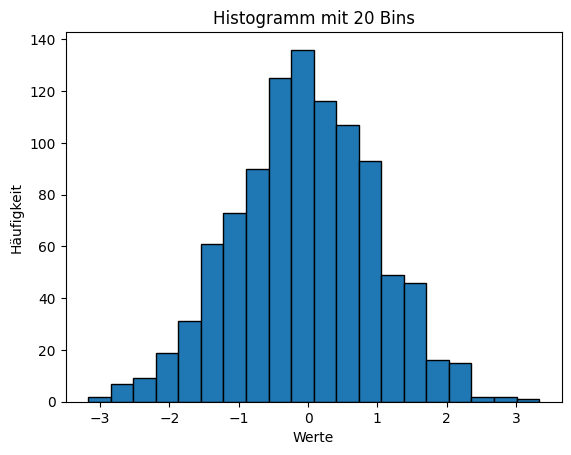

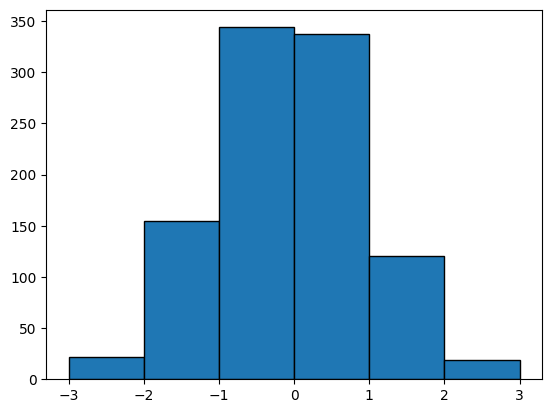

In [10]:
import matplotlib.pyplot as plt
import numpy as np

# Beispieldaten
data = np.random.normal(loc=0, scale=1, size=1000)

# Histogramm mit automatischer Bin-Einteilung
plt.hist(data, bins=20, edgecolor="black")
plt.xlabel("Werte")
plt.ylabel("Häufigkeit")
plt.title("Histogramm mit 20 Bins")
plt.show()

bin_edges = [-3, -2, -1, 0, 1, 2, 3]
plt.hist(data, bins=bin_edges, edgecolor="black")
plt.show()
